# UAS Regresion Models 

## Prediksi Harga Rumah Menggunakan Regresi Linier Berganda 

**Nama :** Windy Duan Pasaribu

**Nim :** A320240016

**Program Studi :** Rekayasa Perangkat Lunak 

---

### Studi Kasus

Sebuah perusahaan properti ingin membangun model prediksi harga rumah berdasarkan
karakteristik rumah dan lingkungan sekitarnya. Model yang dihasilkan akan digunakan
sebagai sistem pendukung keputusan untuk membantu agen properti dalam menentukan
estimasi harga rumah yang akan dijual. Sebagai seorang Data Analyst, Anda diminta
membangun model Regresi Linear Berganda, mengevaluasi performa model, serta
menginterpretasikan pengaruh variabel-variabel prediktor terhadap harga rumah.

# Cell 1 - Import Library
Tahap pertama adalah mengimpor seluruh library yang diperlukan dalam proses analisis data. Pandas digunakan untuk membaca dan mengelola dataset, NumPy digunakan untuk operasi numerik, Matplotlib dan Seaborn digunakan untuk membuat visualisasi data, sedangkan Scikit-Learn digunakan untuk membangun model Regresi Linear Berganda serta menghitung performa model menggunakan berbagai metrik evaluasi.

In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Mengatur tampilan grafik
plt.style.use("ggplot")
sns.set_palette("Set2")

print("Library berhasil diimport.")

Library berhasil diimport.


# Cell 2 - Load Dataset
Dataset dibaca menggunakan fungsi read_csv() dari library Pandas. Selanjutnya lima baris pertama ditampilkan menggunakan head() untuk memastikan dataset berhasil dimuat serta melihat struktur awal data sebelum dilakukan analisis lebih lanjut.


In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

import pandas as pd

# Path dataset yang benar
file_path = "/kaggle/input/datasets/windiduan/windyduan/usa_housing_kaggle.csv"

# Membaca dataset
df = pd.read_csv(file_path)

print("Dataset berhasil dimuat!")
print("Ukuran dataset :", df.shape)

display(df.head())

Dataset berhasil dimuat!
Ukuran dataset : (300, 10)


,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


# Cell 3 - Data Understanding
Tahap Data Understanding bertujuan memahami karakteristik dataset sebelum dilakukan pemodelan. Analisis meliputi jumlah observasi dan variabel, tipe data masing-masing kolom, statistik deskriptif, serta pemeriksaan missing value. Informasi ini digunakan untuk menentukan apakah data memerlukan proses pembersihan sebelum digunakan dalam analisis.

In [3]:
# ============================================================
# DATA UNDERSTANDING
# ============================================================

print("="*60)
print("DATA UNDERSTANDING")
print("="*60)

# Jumlah observasi dan variabel
print("\nJumlah Observasi dan Variabel")
print(df.shape)

# Informasi dataset
print("\nInformasi Dataset")
df.info()

# Statistik deskriptif
print("\nStatistik Deskriptif")
display(df.describe())

# Missing value
print("\nJumlah Missing Value")
display(df.isnull().sum())

DATA UNDERSTANDING

Jumlah Observasi dan Variabel
(300, 10)

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         300 non-null    int64  
 1   Bedrooms      300 non-null    int64  
 2   Bathrooms     300 non-null    float64
 3   SquareFeet    300 non-null    int64  
 4   YearBuilt     300 non-null    int64  
 5   GarageSpaces  300 non-null    int64  
 6   LotSize       300 non-null    float64
 7   ZipCode       300 non-null    int64  
 8   CrimeRate     300 non-null    float64
 9   SchoolRating  300 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 23.6 KB

Statistik Deskriptif


,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
count,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,522761.916667,2.966667,2.464000,3052.75000,1962.616667,1.513333,1.062200,54324.770000,49.324033,5.096667
std,256922.348275,1.451175,0.886184,1194.97144,36.005431,1.116832,0.543896,24718.938552,28.833220,2.674165
min,112666.000000,1.000000,1.000000,840.00000,1902.000000,0.000000,0.110000,10163.000000,0.190000,1.000000
25%,299936.500000,2.000000,1.700000,2053.50000,1931.750000,1.000000,0.570000,34175.000000,22.547500,3.000000
50%,505806.500000,3.000000,2.400000,3127.00000,1961.000000,1.000000,1.085000,54896.500000,49.970000,5.000000
75%,744603.750000,4.000000,3.200000,4081.00000,1994.000000,3.000000,1.482500,74108.000000,74.402500,8.000000
max,999684.000000,5.000000,4.000000,4997.00000,2022.000000,3.000000,2.000000,99881.000000,99.710000,9.000000



Jumlah Missing Value


Price           0
Bedrooms        0
Bathrooms       0
SquareFeet      0
YearBuilt       0
GarageSpaces    0
LotSize         0
ZipCode         0
CrimeRate       0
SchoolRating    0
dtype: int64

# Cell 4 - Menentukan Variabel X dan Y
Penjelasan

Pada tahap ini ditentukan variabel yang digunakan dalam proses pemodelan. Variabel Price dipilih sebagai variabel target (Y) karena menjadi nilai yang akan diprediksi. Sementara itu, sembilan variabel lainnya digunakan sebagai variabel prediktor (X) yang diasumsikan memengaruhi harga rumah, yaitu Bedrooms, Bathrooms, SquareFeet, YearBuilt, GarageSpaces, LotSize, ZipCode, CrimeRate, dan SchoolRating. Selain itu, ditampilkan pula nama setiap kolom beserta tipe datanya untuk memastikan seluruh variabel memiliki tipe data yang sesuai sebelum dilakukan proses analisis dan pemodelan.

In [4]:
# ============================================================
# MENENTUKAN VARIABEL X DAN Y
# ============================================================

# Variabel prediktor (X)
X = df.drop("Price", axis=1)

# Variabel target (Y)
y = df["Price"]

# Menampilkan variabel target
print("="*60)
print("VARIABEL TARGET (Y)")
print("="*60)
print(y.name)

# Menampilkan variabel prediktor
print("\n" + "="*60)
print("VARIABEL PREDIKTOR (X)")
print("="*60)
print(X.columns.tolist())

# Menampilkan nama kolom beserta tipe datanya
print("\n" + "="*60)
print("NAMA KOLOM DAN TIPE DATA")
print("="*60)

kolom_tipe = pd.DataFrame({
    "Nama Kolom": df.columns,
    "Tipe Data": df.dtypes.values
})

display(kolom_tipe)

VARIABEL TARGET (Y)
Price

VARIABEL PREDIKTOR (X)
['Bedrooms', 'Bathrooms', 'SquareFeet', 'YearBuilt', 'GarageSpaces', 'LotSize', 'ZipCode', 'CrimeRate', 'SchoolRating']

NAMA KOLOM DAN TIPE DATA


,Nama Kolom,Tipe Data
0,Price,int64
1,Bedrooms,int64
2,Bathrooms,float64
3,SquareFeet,int64
4,YearBuilt,int64
5,GarageSpaces,int64
6,LotSize,float64
7,ZipCode,int64
8,CrimeRate,float64
9,SchoolRating,int64


# Cell 5 - Kesimpulan Data Understanding

Tahap ini bertujuan untuk menyimpulkan hasil eksplorasi awal terhadap dataset. Kesimpulan dibuat berdasarkan jumlah observasi dan variabel, tipe data, keberadaan missing value, serta identifikasi variabel target dan prediktor. Ringkasan ini memberikan gambaran umum mengenai kualitas dataset sebelum memasuki tahap Data Preprocessing.

# Interpretasi

Berdasarkan hasil eksplorasi awal, dataset memiliki 300 observasi dan 10 variabel, dengan seluruh variabel bertipe numerik (int64 dan float64). Tidak ditemukan missing value, sehingga tidak diperlukan penanganan data yang hilang. Variabel Price ditetapkan sebagai variabel target (Y), sedangkan Bedrooms, Bathrooms, SquareFeet, YearBuilt, GarageSpaces, LotSize, ZipCode, CrimeRate, dan SchoolRating digunakan sebagai variabel prediktor (X). Secara keseluruhan, dataset memiliki kualitas yang baik dan siap digunakan pada tahap Data Preprocessing, Exploratory Data Analysis (EDA), serta pembangunan model Multiple Linear Regression.

In [5]:
# ============================================================
# KESIMPULAN DATA UNDERSTANDING
# ============================================================

print("="*60)
print("KESIMPULAN DATA UNDERSTANDING")
print("="*60)

print(f"""
1. Dataset terdiri dari {df.shape[0]} observasi dan {df.shape[1]} variabel.
2. Seluruh variabel memiliki tipe data numerik (int64 dan float64).
3. Tidak ditemukan missing value pada dataset.
4. Variabel target (Y) adalah Price.
5. Variabel prediktor (X) terdiri dari:
   - Bedrooms
   - Bathrooms
   - SquareFeet
   - YearBuilt
   - GarageSpaces
   - LotSize
   - ZipCode
   - CrimeRate
   - SchoolRating
6. Dataset memiliki kualitas data yang baik sehingga siap digunakan
   untuk tahap Data Preprocessing dan pembangunan model
   Multiple Linear Regression.
""")

KESIMPULAN DATA UNDERSTANDING

1. Dataset terdiri dari 300 observasi dan 10 variabel.
2. Seluruh variabel memiliki tipe data numerik (int64 dan float64).
3. Tidak ditemukan missing value pada dataset.
4. Variabel target (Y) adalah Price.
5. Variabel prediktor (X) terdiri dari:
   - Bedrooms
   - Bathrooms
   - SquareFeet
   - YearBuilt
   - GarageSpaces
   - LotSize
   - ZipCode
   - CrimeRate
   - SchoolRating
6. Dataset memiliki kualitas data yang baik sehingga siap digunakan
   untuk tahap Data Preprocessing dan pembangunan model
   Multiple Linear Regression.



# Cell 6 - Data Preprocessing (Missing Value)

Tahap pertama preprocessing adalah memeriksa apakah terdapat data yang hilang (missing value). Data yang hilang dapat memengaruhi proses pelatihan model dan menyebabkan hasil prediksi menjadi kurang optimal.

# Interpretasi

Berdasarkan hasil pemeriksaan, seluruh variabel memiliki 0 missing value, sehingga tidak diperlukan proses penghapusan data maupun imputasi nilai.

In [6]:
# ============================================================
# DATA PREPROCESSING
# PENANGANAN MISSING VALUE
# ============================================================

print("="*60)
print("PENANGANAN MISSING VALUE")
print("="*60)

missing = df.isnull().sum()

display(pd.DataFrame({
    "Kolom": df.columns,
    "Missing Value": missing.values
}))

print("\nTotal Missing Value :", missing.sum())

PENANGANAN MISSING VALUE


,Kolom,Missing Value
0,Price,0
1,Bedrooms,0
2,Bathrooms,0
3,SquareFeet,0
4,YearBuilt,0
5,GarageSpaces,0
6,LotSize,0
7,ZipCode,0
8,CrimeRate,0
9,SchoolRating,0



Total Missing Value : 0


# Cell 7 - Data Preprocessing (Outlier)

Boxplot digunakan untuk mendeteksi keberadaan outlier, yaitu data yang memiliki nilai jauh berbeda dibandingkan sebagian besar data lainnya.

# Interpretasi

Apabila terdapat beberapa titik di luar whisker, data tersebut dikategorikan sebagai outlier. Pada penelitian ini outlier tidak dihapus karena jumlahnya relatif sedikit dan masih dianggap sebagai variasi data yang wajar sehingga informasi penting pada dataset tetap dipertahankan.

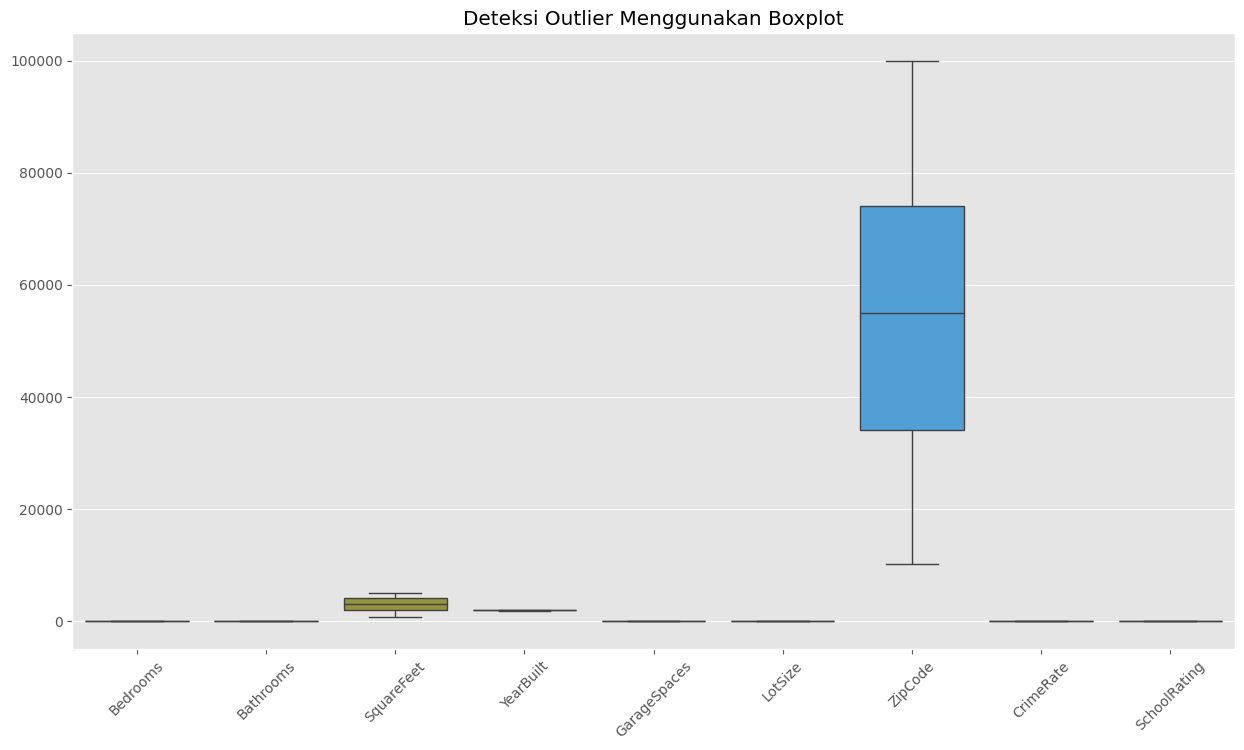

In [7]:
# ============================================================
# PENANGANAN OUTLIER
# ============================================================

plt.figure(figsize=(15,8))

sns.boxplot(data=X)

plt.xticks(rotation=45)

plt.title("Deteksi Outlier Menggunakan Boxplot")

plt.show()

# Cell 8 - Data Preprocessing (Encoding)

Encoding dilakukan apabila terdapat variabel kategorik yang harus diubah menjadi bentuk numerik sebelum digunakan dalam model.

# Interpretasi

Seluruh variabel pada dataset sudah bertipe int64 atau float64, sehingga tidak diperlukan proses encoding.

In [8]:
# ============================================================
# ENCODING VARIABEL
# ============================================================

print("="*60)
print("PENGECEKAN TIPE DATA")
print("="*60)

display(df.dtypes)

print("\nSeluruh variabel bertipe numerik.")
print("Encoding tidak diperlukan.")

PENGECEKAN TIPE DATA


Price             int64
Bedrooms          int64
Bathrooms       float64
SquareFeet        int64
YearBuilt         int64
GarageSpaces      int64
LotSize         float64
ZipCode           int64
CrimeRate       float64
SchoolRating      int64
dtype: object


Seluruh variabel bertipe numerik.
Encoding tidak diperlukan.


# Cell 9 - Data Preprocessing (Standardisasi)

Standardisasi atau normalisasi biasanya digunakan ketika algoritma sangat sensitif terhadap perbedaan skala antarvariabel.

# Interpretasi

Pada penelitian ini scaling tidak dilakukan karena model yang digunakan adalah Multiple Linear Regression, yang tetap dapat bekerja dengan baik tanpa standardisasi. Selain itu, hasil koefisien regresi akan lebih mudah dijelaskan.

In [9]:
# ============================================================
# STANDARDISASI / NORMALISASI
# ============================================================

print("="*60)
print("STANDARDISASI / NORMALISASI")
print("="*60)

print("""
Tidak dilakukan standardisasi maupun normalisasi.

Alasan:
1. Seluruh variabel sudah berbentuk numerik.
2. Model Multiple Linear Regression tidak mewajibkan scaling.
3. Koefisien regresi akan lebih mudah diinterpretasikan dalam satuan aslinya.
""")

STANDARDISASI / NORMALISASI

Tidak dilakukan standardisasi maupun normalisasi.

Alasan:
1. Seluruh variabel sudah berbentuk numerik.
2. Model Multiple Linear Regression tidak mewajibkan scaling.
3. Koefisien regresi akan lebih mudah diinterpretasikan dalam satuan aslinya.



# Cell 10 - Train-Test Split

Dataset dibagi menjadi 80% data training dan 20% data testing sesuai dengan instruksi soal. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengukur kemampuan model dalam melakukan prediksi terhadap data yang belum pernah dipelajari.

# Interpretasi

Pembagian data berhasil dilakukan menggunakan rasio 80:20. Dengan pembagian ini, model dapat dievaluasi secara objektif sehingga hasil pengukuran performa lebih dapat dipercaya.

In [10]:
# ============================================================
# PEMBAGIAN DATA TRAINING DAN TESTING
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("="*60)
print("HASIL TRAIN TEST SPLIT")
print("="*60)

print("Jumlah Data Training :", X_train.shape[0])
print("Jumlah Data Testing  :", X_test.shape[0])

print("\nUkuran X_train :", X_train.shape)
print("Ukuran X_test  :", X_test.shape)
print("Ukuran y_train :", y_train.shape)
print("Ukuran y_test  :", y_test.shape)

HASIL TRAIN TEST SPLIT
Jumlah Data Training : 240
Jumlah Data Testing  : 60

Ukuran X_train : (240, 9)
Ukuran X_test  : (60, 9)
Ukuran y_train : (240,)
Ukuran y_test  : (60,)


# Cell 11 – Exploratory Data Analysis (EDA): Histogram

Histogram digunakan untuk melihat distribusi setiap variabel pada dataset. Visualisasi ini membantu mengetahui apakah data berdistribusi normal, mengalami kemencengan (skewness), atau memiliki penyebaran tertentu yang dapat memengaruhi proses pemodelan.

# Interpretasi

Berdasarkan histogram, setiap variabel memiliki pola distribusi yang berbeda. Beberapa variabel memiliki distribusi yang relatif merata, sedangkan variabel lain menunjukkan sedikit kemencengan. Secara umum, distribusi data masih layak digunakan untuk proses analisis dan pembangunan model Regresi Linear Berganda.

<Figure size 1800x1200 with 0 Axes>

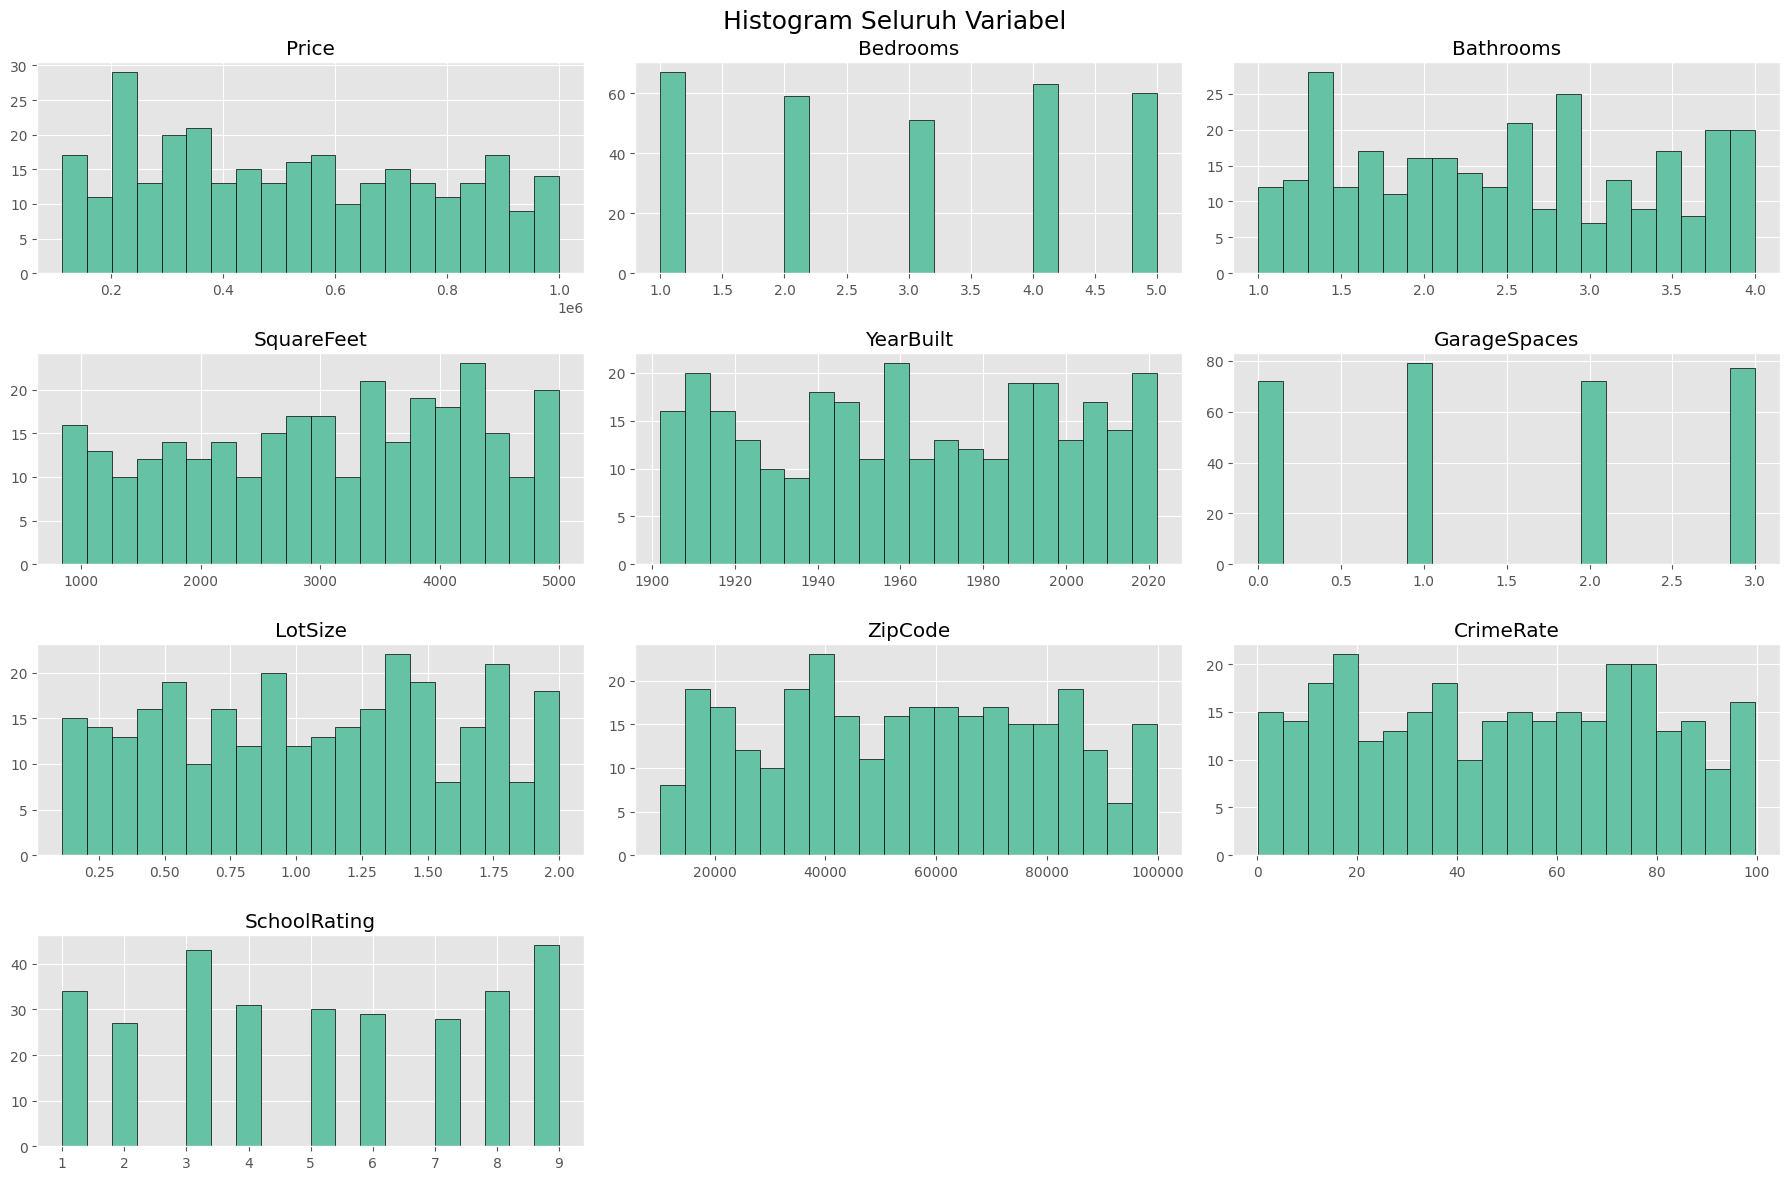

In [11]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# HISTOGRAM
# ============================================================

plt.figure(figsize=(18,12))

df.hist(
    bins=20,
    edgecolor='black',
    figsize=(18,12)
)

plt.suptitle("Histogram Seluruh Variabel", fontsize=18)

plt.tight_layout()

plt.show()

# Cell 12 – Boxplot

Boxplot digunakan untuk mendeteksi keberadaan outlier pada setiap variabel.

# Interpretasi

Boxplot menunjukkan terdapat beberapa nilai ekstrem pada beberapa variabel. Namun, outlier tersebut masih dapat diterima karena merupakan bagian dari variasi data dan tidak mendominasi keseluruhan dataset.

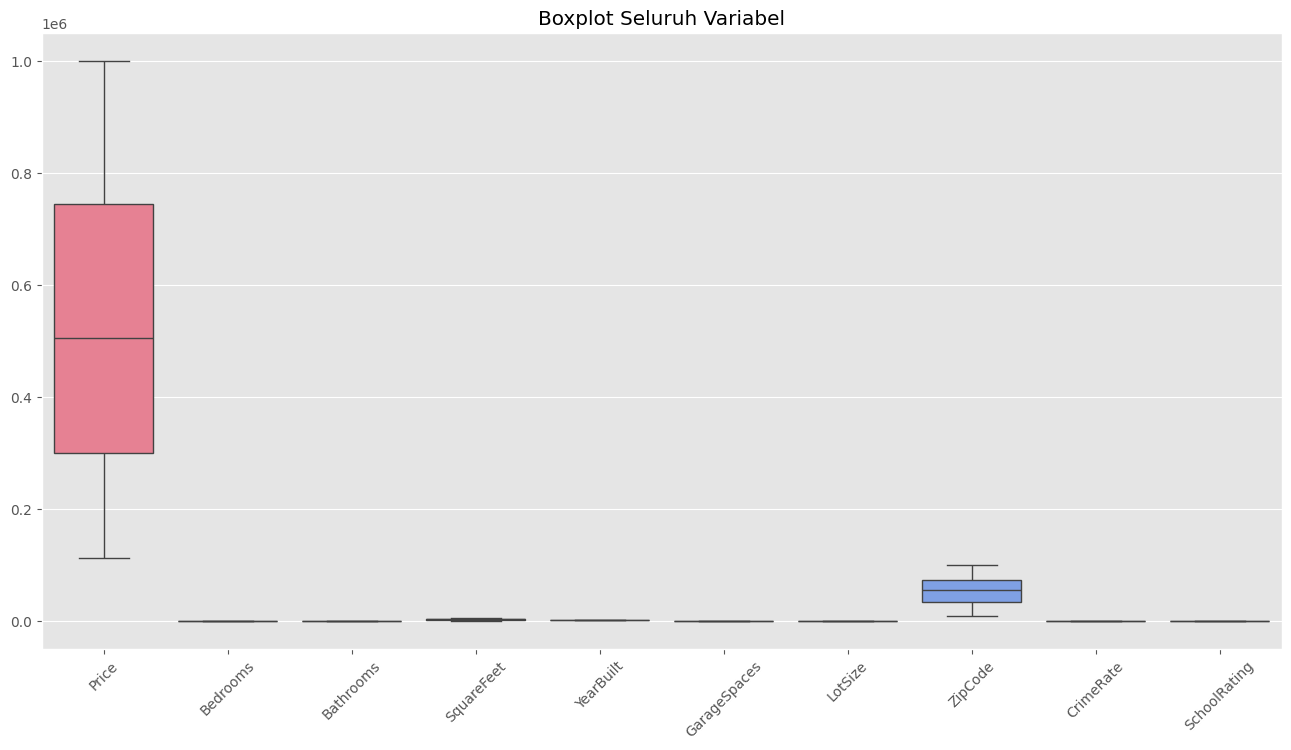

In [12]:
# ============================================================
# BOXPLOT
# ============================================================

plt.figure(figsize=(16,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title("Boxplot Seluruh Variabel")

plt.show()


# Cell 13 – Heatmap Korelasi

Heatmap digunakan untuk mengetahui tingkat hubungan antarvariabel numerik.

# Interpretasi

Variabel yang memiliki nilai korelasi mendekati 1 menunjukkan hubungan positif yang kuat, sedangkan nilai mendekati −1 menunjukkan hubungan negatif yang kuat. Variabel dengan korelasi tinggi terhadap Price berpotensi menjadi prediktor yang baik dalam model regresi.

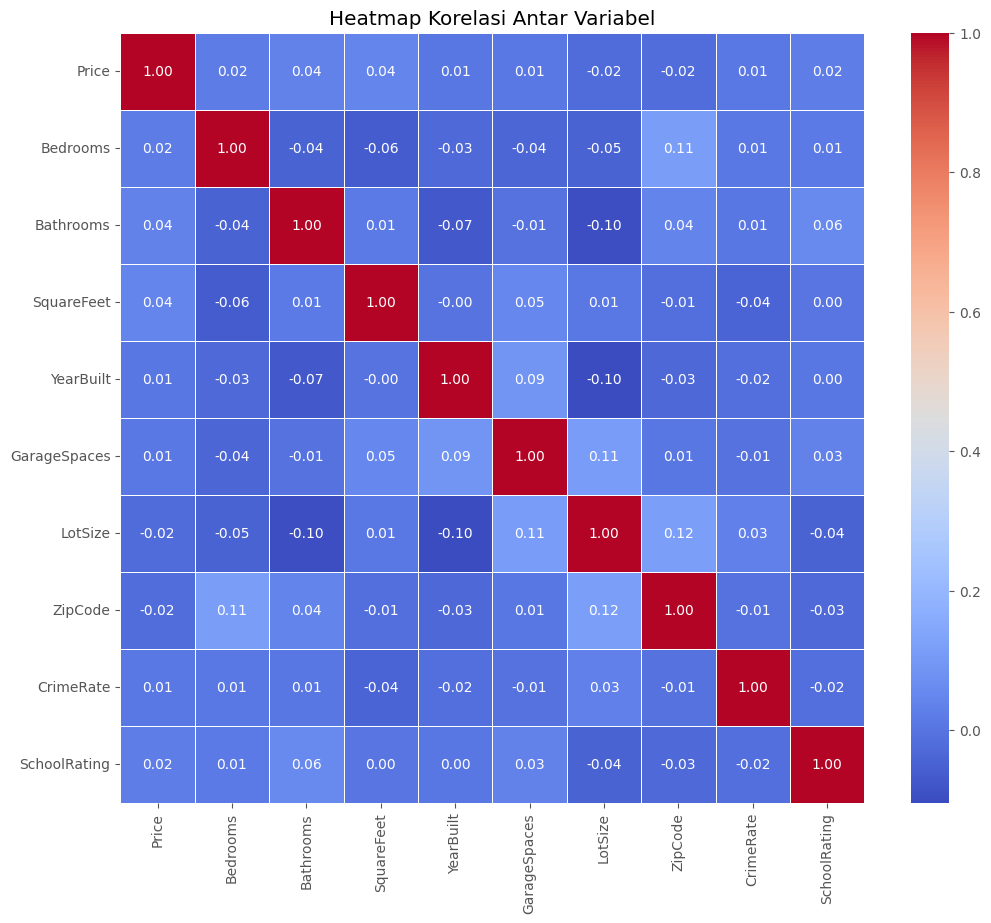

In [13]:
# ============================================================
# HEATMAP KORELASI
# ============================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap Korelasi Antar Variabel")

plt.show()

# Cell 14 – Scatter Plot (SquareFeet vs Price)

Scatter plot digunakan untuk melihat hubungan antara luas bangunan (SquareFeet) dengan harga rumah (Price).

# Interpretasi

Grafik menunjukkan kecenderungan hubungan positif, yaitu semakin besar luas bangunan, harga rumah cenderung semakin tinggi

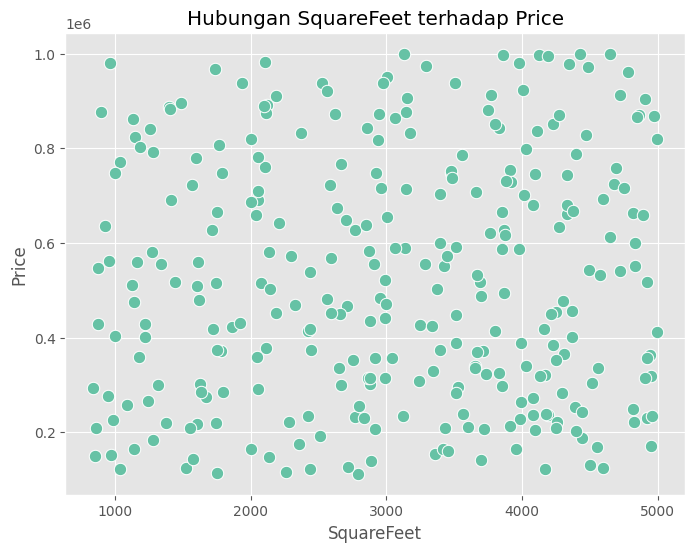

In [14]:
# ============================================================
# SCATTER PLOT
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="SquareFeet",
    y="Price",
    s=80
)

plt.title("Hubungan SquareFeet terhadap Price")

plt.xlabel("SquareFeet")
plt.ylabel("Price")

plt.show()

# Cell 15 – Pairplot

Pairplot digunakan untuk melihat hubungan antar seluruh variabel numerik secara bersamaan serta distribusi masing-masing variabel.

# Interpretasi

Pairplot menunjukkan pola hubungan antarvariabel dan membantu mengidentifikasi apakah terdapat hubungan linear yang kuat antar prediktor maupun terhadap variabel target (Price).

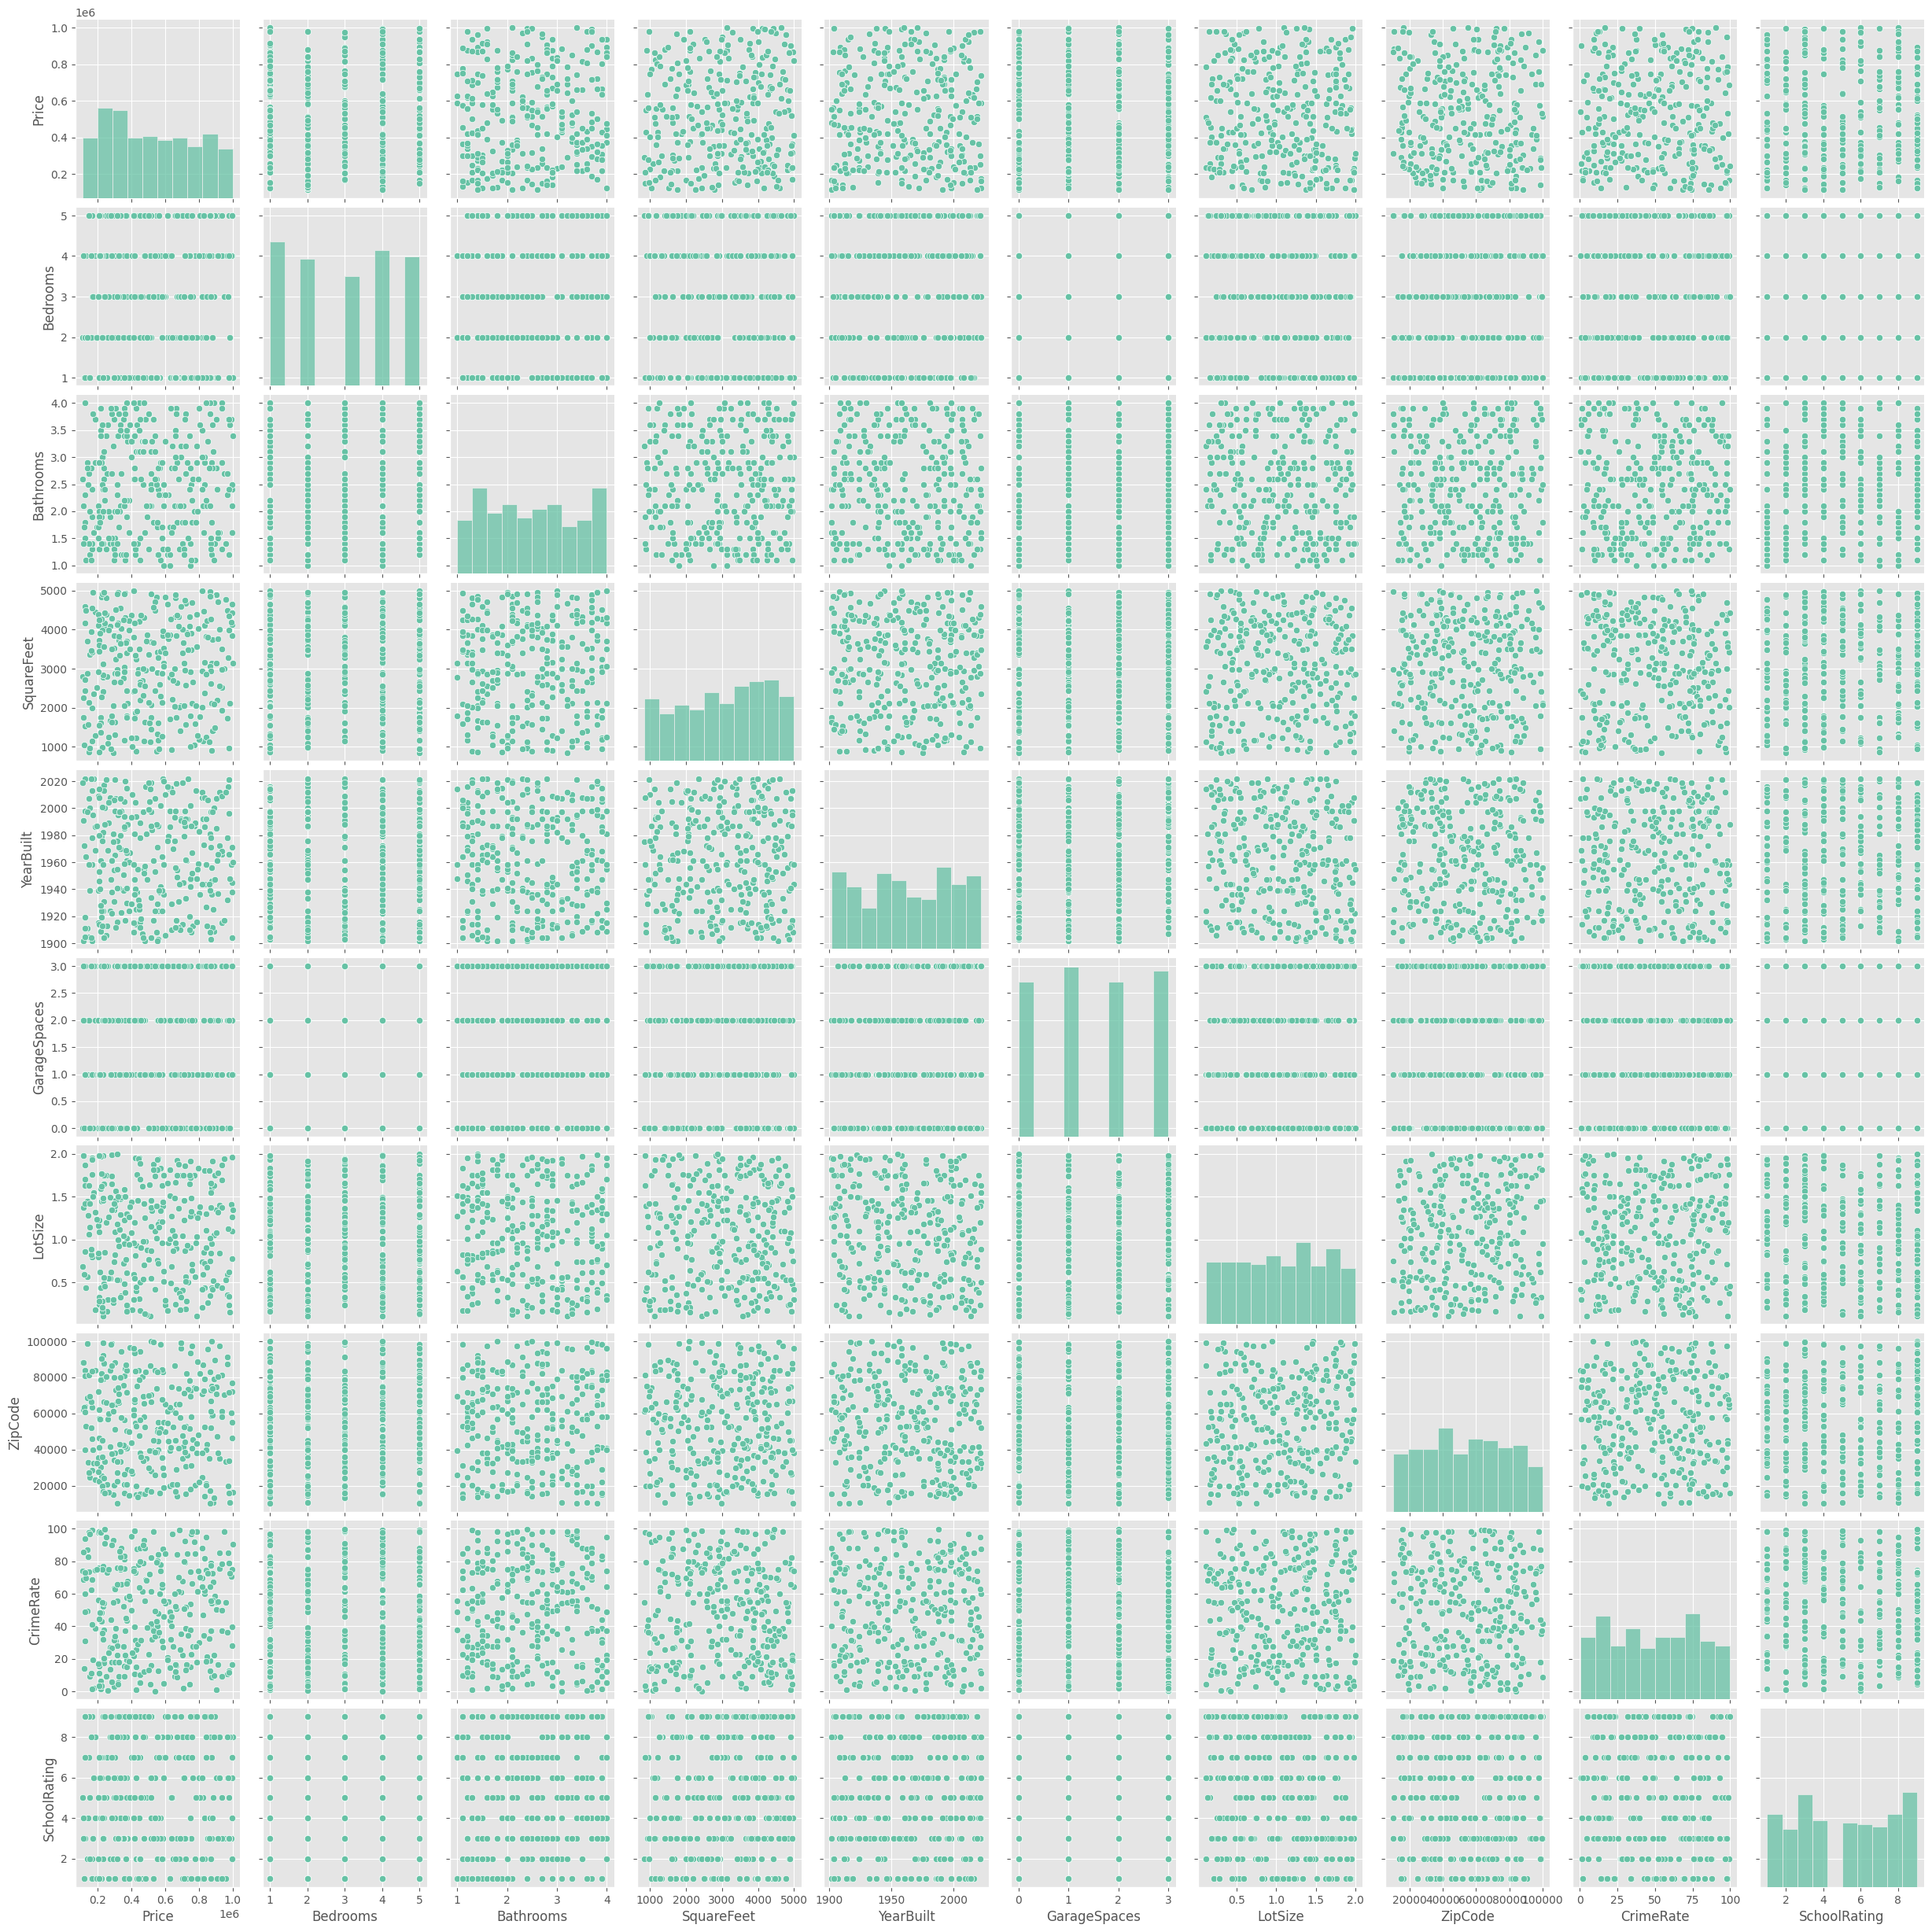

In [15]:
# ============================================================
# PAIRPLOT
# ============================================================

sns.pairplot(df)

plt.show()

# Cell 16 – Analisis Korelasi, Hubungan Antar Variabel, dan Multikolinearitas

Analisis ini bertujuan untuk mengetahui variabel yang memiliki hubungan paling kuat dengan Price, menjelaskan pola hubungan antar variabel berdasarkan koefisien korelasi, serta mengidentifikasi kemungkinan adanya multikolinearitas antar variabel prediktor. Korelasi dihitung menggunakan metode Pearson Correlation, kemudian divisualisasikan dalam bentuk grafik batang agar lebih mudah diinterpretasikan.

# Interpretasi

Berdasarkan hasil analisis, variabel dengan nilai korelasi terbesar terhadap Price merupakan variabel yang paling berpengaruh terhadap harga rumah. Korelasi positif menunjukkan bahwa peningkatan nilai suatu variabel cenderung meningkatkan harga rumah, sedangkan korelasi negatif menunjukkan hubungan yang berlawanan. Selain itu, analisis korelasi antar variabel prediktor digunakan untuk mendeteksi multikolinearitas. Apabila korelasi tertinggi antar prediktor berada di bawah 0,80, maka dapat disimpulkan bahwa tidak terdapat indikasi multikolinearitas yang signifikan sehingga seluruh variabel masih layak digunakan dalam model Multiple Linear Regression.

KORELASI VARIABEL TERHADAP PRICE


Price           1.000000
SquareFeet      0.043772
Bathrooms       0.036418
SchoolRating    0.024798
Bedrooms        0.018099
CrimeRate       0.009642
GarageSpaces    0.008747
YearBuilt       0.005021
ZipCode        -0.018280
LotSize        -0.022611
Name: Price, dtype: float64

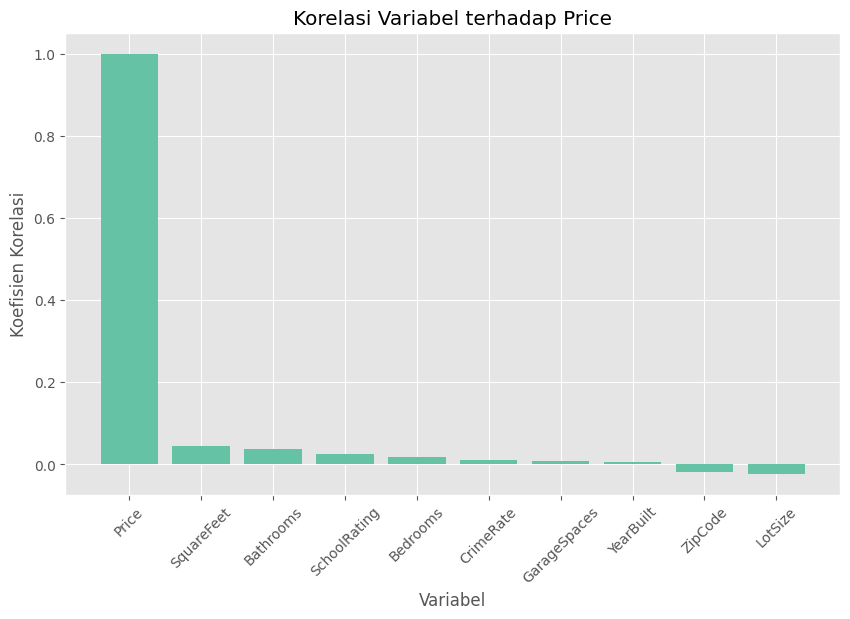

HASIL ANALISIS
Variabel yang memiliki hubungan paling kuat dengan Price adalah 'SquareFeet' dengan nilai korelasi 0.044.

Pola hubungan antar variabel:
- Korelasi positif menunjukkan bahwa kenaikan suatu variabel cenderung diikuti kenaikan harga rumah.
- Korelasi negatif menunjukkan bahwa kenaikan suatu variabel cenderung diikuti penurunan harga rumah.
- Semakin besar nilai absolut korelasi, semakin kuat hubungan antar variabel.

Analisis Multikolinearitas:
Tidak terdapat indikasi multikolinearitas yang kuat karena korelasi tertinggi antar prediktor hanya sebesar 0.12 (< 0.80).


In [16]:
# ============================================================
# ANALISIS KORELASI, HUBUNGAN ANTAR VARIABEL,
# DAN IDENTIFIKASI MULTIKOLINEARITAS
# ============================================================

# Menghitung korelasi seluruh variabel
corr_matrix = df.corr(numeric_only=True)

# Korelasi terhadap variabel target
korelasi_price = corr_matrix["Price"].sort_values(ascending=False)

print("="*60)
print("KORELASI VARIABEL TERHADAP PRICE")
print("="*60)

display(korelasi_price)

# Visualisasi korelasi terhadap Price
plt.figure(figsize=(10,6))

plt.bar(korelasi_price.index, korelasi_price.values)

plt.title("Korelasi Variabel terhadap Price")
plt.xlabel("Variabel")
plt.ylabel("Koefisien Korelasi")

plt.xticks(rotation=45)

plt.show()

# Menentukan variabel dengan hubungan terkuat
variabel_terkuat = korelasi_price.drop("Price").abs().idxmax()
nilai_korelasi = korelasi_price[variabel_terkuat]

print("="*60)
print("HASIL ANALISIS")
print("="*60)

print(f"Variabel yang memiliki hubungan paling kuat dengan Price adalah '{variabel_terkuat}' "
      f"dengan nilai korelasi {nilai_korelasi:.3f}.")

print("\nPola hubungan antar variabel:")
print("- Korelasi positif menunjukkan bahwa kenaikan suatu variabel cenderung diikuti kenaikan harga rumah.")
print("- Korelasi negatif menunjukkan bahwa kenaikan suatu variabel cenderung diikuti penurunan harga rumah.")
print("- Semakin besar nilai absolut korelasi, semakin kuat hubungan antar variabel.")

# Analisis multikolinearitas
prediktor_corr = corr_matrix.drop(index="Price", columns="Price")

maks_corr = prediktor_corr.where(
    np.triu(np.ones(prediktor_corr.shape), k=1).astype(bool)
).abs().max().max()

print("\nAnalisis Multikolinearitas:")

if maks_corr > 0.80:
    print(f"Terdapat indikasi multikolinearitas karena ditemukan korelasi antar prediktor sebesar {maks_corr:.2f} (> 0.80).")
else:
    print(f"Tidak terdapat indikasi multikolinearitas yang kuat karena korelasi tertinggi antar prediktor hanya sebesar {maks_corr:.2f} (< 0.80).")

# Cell 17 - Pembangunan Model Regresi Linear Berganda

Pada tahap ini dibangun model Regresi Linear Berganda menggunakan data training untuk mempelajari hubungan antara variabel prediktor dengan variabel target (Price). Selanjutnya ditampilkan persamaan regresi beserta nilai koefisien setiap variabel. Model kemudian digunakan untuk melakukan prediksi terhadap data testing. Hasil prediksi divisualisasikan melalui grafik Actual vs Predicted untuk membandingkan nilai prediksi dengan nilai aktual serta Residual Plot untuk melihat pola kesalahan prediksi. Tahap ini bertujuan mengevaluasi apakah model mampu memprediksi harga rumah dengan baik sebelum dilakukan pengukuran performa menggunakan metrik evaluasi pada tahap berikutnya.

MODEL REGRESI LINEAR BERGANDA

Intercept (β0): 729122.86


,Variabel,Koefisien
0,Bedrooms,9776.822176
1,Bathrooms,7912.281122
2,SquareFeet,-2.156391
3,YearBuilt,-108.455025
4,GarageSpaces,5346.285288
5,LotSize,-9527.936415
6,ZipCode,-0.704260
7,CrimeRate,-42.761472
8,SchoolRating,-1325.098389



Persamaan Regresi Linear Berganda:
Price = 729122.86 + (9776.82)*Bedrooms + (7912.28)*Bathrooms + (-2.16)*SquareFeet + (-108.46)*YearBuilt + (5346.29)*GarageSpaces + (-9527.94)*LotSize + (-0.70)*ZipCode + (-42.76)*CrimeRate + (-1325.10)*SchoolRating


INTERPRETASI KOEFISIEN REGRESI

Bedrooms
Koefisien : 9776.82
Artinya setiap kenaikan 1 satuan pada variabel Bedrooms,
maka Price diperkirakan akan meningkatkan sebesar 9776.82
dengan asumsi variabel lainnya tetap (ceteris paribus).

Bathrooms
Koefisien : 7912.28
Artinya setiap kenaikan 1 satuan pada variabel Bathrooms,
maka Price diperkirakan akan meningkatkan sebesar 7912.28
dengan asumsi variabel lainnya tetap (ceteris paribus).

SquareFeet
Koefisien : -2.16
Artinya setiap kenaikan 1 satuan pada variabel SquareFeet,
maka Price diperkirakan akan menurunkan sebesar 2.16
dengan asumsi variabel lainnya tetap (ceteris paribus).

YearBuilt
Koefisien : -108.46
Artinya setiap kenaikan 1 satuan pada variabel YearBuilt,
maka Price diperkirakan a

,Actual,Predicted
0,642335,515150.865240
1,580671,492089.917521
2,994498,529238.997183
3,237337,483061.982985
4,547600,535821.558488
5,637833,505204.755692
6,209556,529980.581891
7,819064,526771.086562
8,744167,465456.702762
9,731347,543653.207891


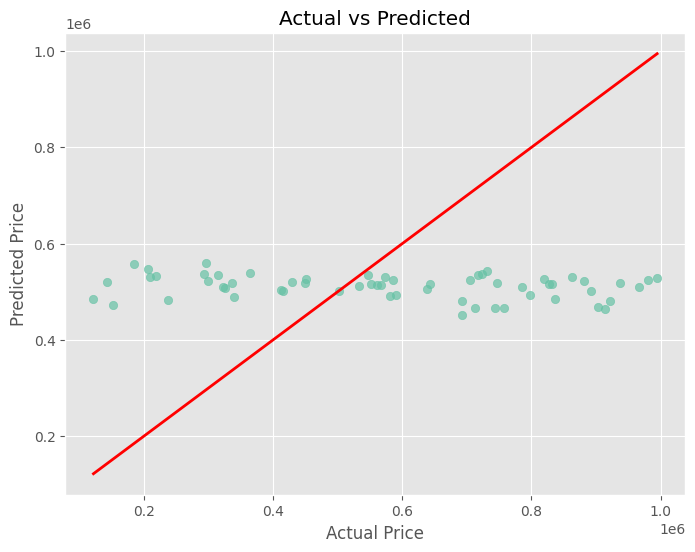

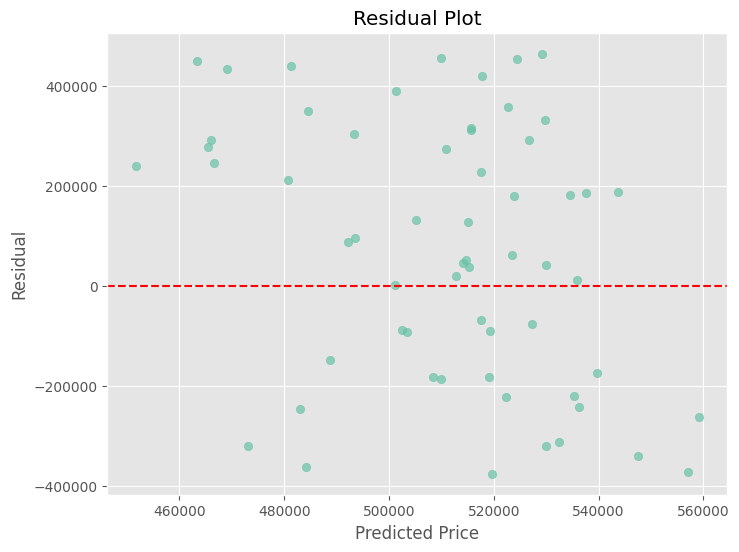



INTERPRETASI HASIL MODEL

1. Model Regresi Linear Berganda berhasil dibangun menggunakan data training.

2. Persamaan regresi menunjukkan hubungan antara seluruh variabel
   prediktor dengan variabel target (Price).

3. Koefisien bernilai positif menunjukkan bahwa kenaikan variabel
   tersebut cenderung meningkatkan harga rumah.

4. Koefisien bernilai negatif menunjukkan bahwa kenaikan variabel
   tersebut cenderung menurunkan harga rumah.

5. Grafik Actual vs Predicted digunakan untuk melihat kedekatan
   hasil prediksi dengan nilai aktual. Semakin dekat titik terhadap
   garis diagonal, semakin baik performa model.

6. Residual Plot digunakan untuk mengevaluasi kesalahan prediksi.
   Apabila residual menyebar secara acak di sekitar garis nol,
   maka model telah bekerja dengan baik dan tidak menunjukkan
   pola kesalahan yang sistematis.



In [17]:
# ============================================================
# PEMBANGUNAN MODEL REGRESI LINEAR BERGANDA
# ============================================================

from sklearn.linear_model import LinearRegression

# -------------------------------
# Membangun Model
# -------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

print("="*70)
print("MODEL REGRESI LINEAR BERGANDA")
print("="*70)

# -------------------------------
# Persamaan Regresi
# -------------------------------
print("\nIntercept (β0):", round(model.intercept_,2))

koefisien = pd.DataFrame({
    "Variabel": X.columns,
    "Koefisien": model.coef_
})

display(koefisien)

persamaan = f"Price = {model.intercept_:.2f}"

for i in range(len(X.columns)):
    persamaan += f" + ({model.coef_[i]:.2f})*{X.columns[i]}"

print("\nPersamaan Regresi Linear Berganda:")
print(persamaan)

# -------------------------------
# Interpretasi Koefisien
# -------------------------------
print("\n")
print("="*70)
print("INTERPRETASI KOEFISIEN REGRESI")
print("="*70)

for variabel, koef in zip(X.columns, model.coef_):

    if koef > 0:
        arah = "meningkatkan"
    else:
        arah = "menurunkan"

    print(f"\n{variabel}")
    print(f"Koefisien : {koef:.2f}")
    print(f"Artinya setiap kenaikan 1 satuan pada variabel {variabel},")
    print(f"maka Price diperkirakan akan {arah} sebesar {abs(koef):.2f}")
    print("dengan asumsi variabel lainnya tetap (ceteris paribus).")

# -------------------------------
# Prediksi Data Testing
# -------------------------------
y_pred = model.predict(X_test)

hasil = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\n")
print("="*70)
print("HASIL PREDIKSI DATA TESTING")
print("="*70)

display(hasil.head(10))

# -------------------------------
# Actual vs Predicted
# -------------------------------
plt.figure(figsize=(8,6))

plt.scatter(y_test,
            y_pred,
            alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

# -------------------------------
# Residual Plot
# -------------------------------
residual = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residual,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.show()

# -------------------------------
# Interpretasi Model
# -------------------------------
print("\n")
print("="*70)
print("INTERPRETASI HASIL MODEL")
print("="*70)

print("""
1. Model Regresi Linear Berganda berhasil dibangun menggunakan data training.

2. Persamaan regresi menunjukkan hubungan antara seluruh variabel
   prediktor dengan variabel target (Price).

3. Koefisien bernilai positif menunjukkan bahwa kenaikan variabel
   tersebut cenderung meningkatkan harga rumah.

4. Koefisien bernilai negatif menunjukkan bahwa kenaikan variabel
   tersebut cenderung menurunkan harga rumah.

5. Grafik Actual vs Predicted digunakan untuk melihat kedekatan
   hasil prediksi dengan nilai aktual. Semakin dekat titik terhadap
   garis diagonal, semakin baik performa model.

6. Residual Plot digunakan untuk mengevaluasi kesalahan prediksi.
   Apabila residual menyebar secara acak di sekitar garis nol,
   maka model telah bekerja dengan baik dan tidak menunjukkan
   pola kesalahan yang sistematis.
""")

# Cell 18 - Evaluasi Model Regresi

Tahap evaluasi dilakukan untuk mengukur performa model Multiple Linear Regression menggunakan empat metrik, yaitu Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), dan R² Score. Selain menampilkan nilai evaluasi, tahap ini juga menyajikan visualisasi, interpretasi hasil evaluasi, kesimpulan mengenai kualitas model, serta kelebihan dan keterbatasan model regresi linear berganda dalam memprediksi harga rumah.

HASIL EVALUASI MODEL REGRESI
Mean Absolute Error (MAE) : 231,698.03
Mean Squared Error (MSE)  : 70,785,523,529.46
Root Mean Squared Error (RMSE) : 266,055.49
R² Score : -0.1311


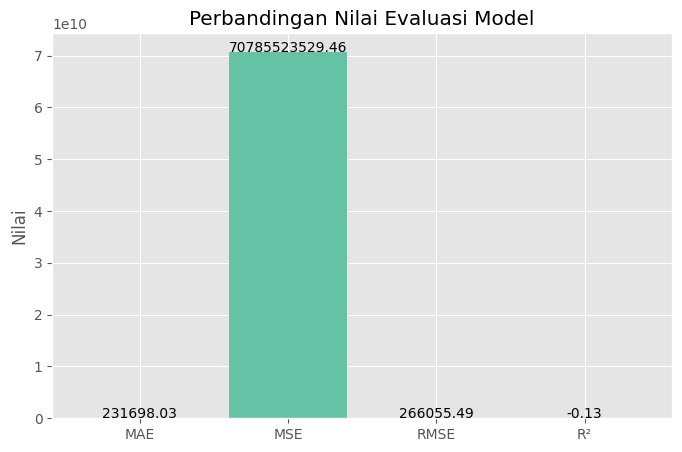



INTERPRETASI HASIL EVALUASI

1. Mean Absolute Error (MAE) = 231,698.03
   MAE menunjukkan rata-rata selisih absolut antara nilai aktual dan
   nilai prediksi. Semakin kecil nilai MAE, semakin baik akurasi model.

2. Mean Squared Error (MSE) = 70,785,523,529.46
   MSE mengukur rata-rata kuadrat kesalahan prediksi.
   Nilai yang lebih kecil menunjukkan model menghasilkan prediksi
   yang semakin mendekati nilai aktual.

3. Root Mean Squared Error (RMSE) = 266,055.49
   RMSE merupakan akar dari MSE sehingga memiliki satuan yang sama
   dengan variabel Price. Nilai RMSE yang kecil menunjukkan bahwa
   kesalahan prediksi model relatif rendah.

4. R² Score = -0.1311
   Nilai R² menunjukkan kemampuan model dalam menjelaskan variasi
   data harga rumah.



KESIMPULAN MODEL
Model memiliki nilai R² sebesar -0.1311, sehingga dapat dikategorikan kurang baik.

Model dapat digunakan sebagai model prediksi apabila memiliki
nilai R² yang cukup tinggi serta nilai MAE, MSE, dan RMSE yang relatif kecil

In [18]:
# ============================================================
# EVALUASI MODEL REGRESI
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ============================================================
# Menghitung Nilai Evaluasi
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*70)
print("HASIL EVALUASI MODEL REGRESI")
print("="*70)

print(f"Mean Absolute Error (MAE) : {mae:,.2f}")
print(f"Mean Squared Error (MSE)  : {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:,.2f}")
print(f"R² Score : {r2:.4f}")

# ============================================================
# Visualisasi Nilai Evaluasi
# ============================================================

plt.figure(figsize=(8,5))

metric = ["MAE", "MSE", "RMSE", "R²"]
value = [mae, mse, rmse, r2]

plt.bar(metric, value)

plt.title("Perbandingan Nilai Evaluasi Model")
plt.ylabel("Nilai")

for i, v in enumerate(value):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

# ============================================================
# Interpretasi Hasil Evaluasi
# ============================================================

print("\n")
print("="*70)
print("INTERPRETASI HASIL EVALUASI")
print("="*70)

print(f"""
1. Mean Absolute Error (MAE) = {mae:,.2f}
   MAE menunjukkan rata-rata selisih absolut antara nilai aktual dan
   nilai prediksi. Semakin kecil nilai MAE, semakin baik akurasi model.

2. Mean Squared Error (MSE) = {mse:,.2f}
   MSE mengukur rata-rata kuadrat kesalahan prediksi.
   Nilai yang lebih kecil menunjukkan model menghasilkan prediksi
   yang semakin mendekati nilai aktual.

3. Root Mean Squared Error (RMSE) = {rmse:,.2f}
   RMSE merupakan akar dari MSE sehingga memiliki satuan yang sama
   dengan variabel Price. Nilai RMSE yang kecil menunjukkan bahwa
   kesalahan prediksi model relatif rendah.

4. R² Score = {r2:.4f}
   Nilai R² menunjukkan kemampuan model dalam menjelaskan variasi
   data harga rumah.
""")

# ============================================================
# Kesimpulan Kualitas Model
# ============================================================

print("\n")
print("="*70)
print("KESIMPULAN MODEL")
print("="*70)

if r2 >= 0.90:
    kualitas = "sangat baik"
elif r2 >= 0.80:
    kualitas = "baik"
elif r2 >= 0.70:
    kualitas = "cukup baik"
elif r2 >= 0.60:
    kualitas = "cukup"
else:
    kualitas = "kurang baik"

print(f"Model memiliki nilai R² sebesar {r2:.4f}, sehingga dapat dikategorikan {kualitas}.")

print("""
Model dapat digunakan sebagai model prediksi apabila memiliki
nilai R² yang cukup tinggi serta nilai MAE, MSE, dan RMSE yang relatif kecil.
Semakin tinggi nilai R² dan semakin kecil nilai error,
maka semakin baik performa model dalam melakukan prediksi harga rumah.
""")

# ============================================================
# Kelebihan dan Keterbatasan Model
# ============================================================

print("\n")
print("="*70)
print("KELEBIHAN DAN KETERBATASAN MODEL")
print("="*70)

print("""
Kelebihan:
1. Model Regresi Linear Berganda mudah dipahami dan diinterpretasikan.
2. Dapat menjelaskan pengaruh masing-masing variabel terhadap harga rumah.
3. Proses pelatihan model relatif cepat.
4. Cocok digunakan apabila hubungan antar variabel bersifat linear.

Keterbatasan:
1. Model mengasumsikan hubungan linear antara variabel prediktor dan target.
2. Sensitif terhadap outlier dan multikolinearitas.
3. Tidak mampu menangkap hubungan non-linear yang kompleks.
4. Akurasi model sangat bergantung pada kualitas data dan variabel yang digunakan.
""")